# Notebook 03: EDA for Decisions

Notebook này trả lời 12 câu hỏi quan trọng để ra quyết định cho quá trình Feature Engineering và Modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 1. Dữ liệu tổng hợp theo ngày

Để phân tích vĩ mô, nạp sẵn một số tập dữ liệu đã tổng hợp.

In [2]:
train_daily = pd.read_csv('../data/interim/train_daily.csv', parse_dates=['date'])
train_store_day = pd.read_csv('../data/interim/train_store_day.csv', parse_dates=['date'])


## Q1: Doanh số tăng vì mỗi món bán nhiều hơn, hay vì có thêm cửa hàng/món?

Chúng ta sẽ xem xét 3 biểu đồ theo thời gian:
1. Tổng doanh số mỗi ngày (`sales_sum`).
2. Số lượng cửa hàng và số lượng món hàng bán được mỗi ngày.
3. Trung bình doanh số trên mỗi giao dịch (mỗi dòng của một món tại một cửa hàng) = `sales_sum / n_rows`.

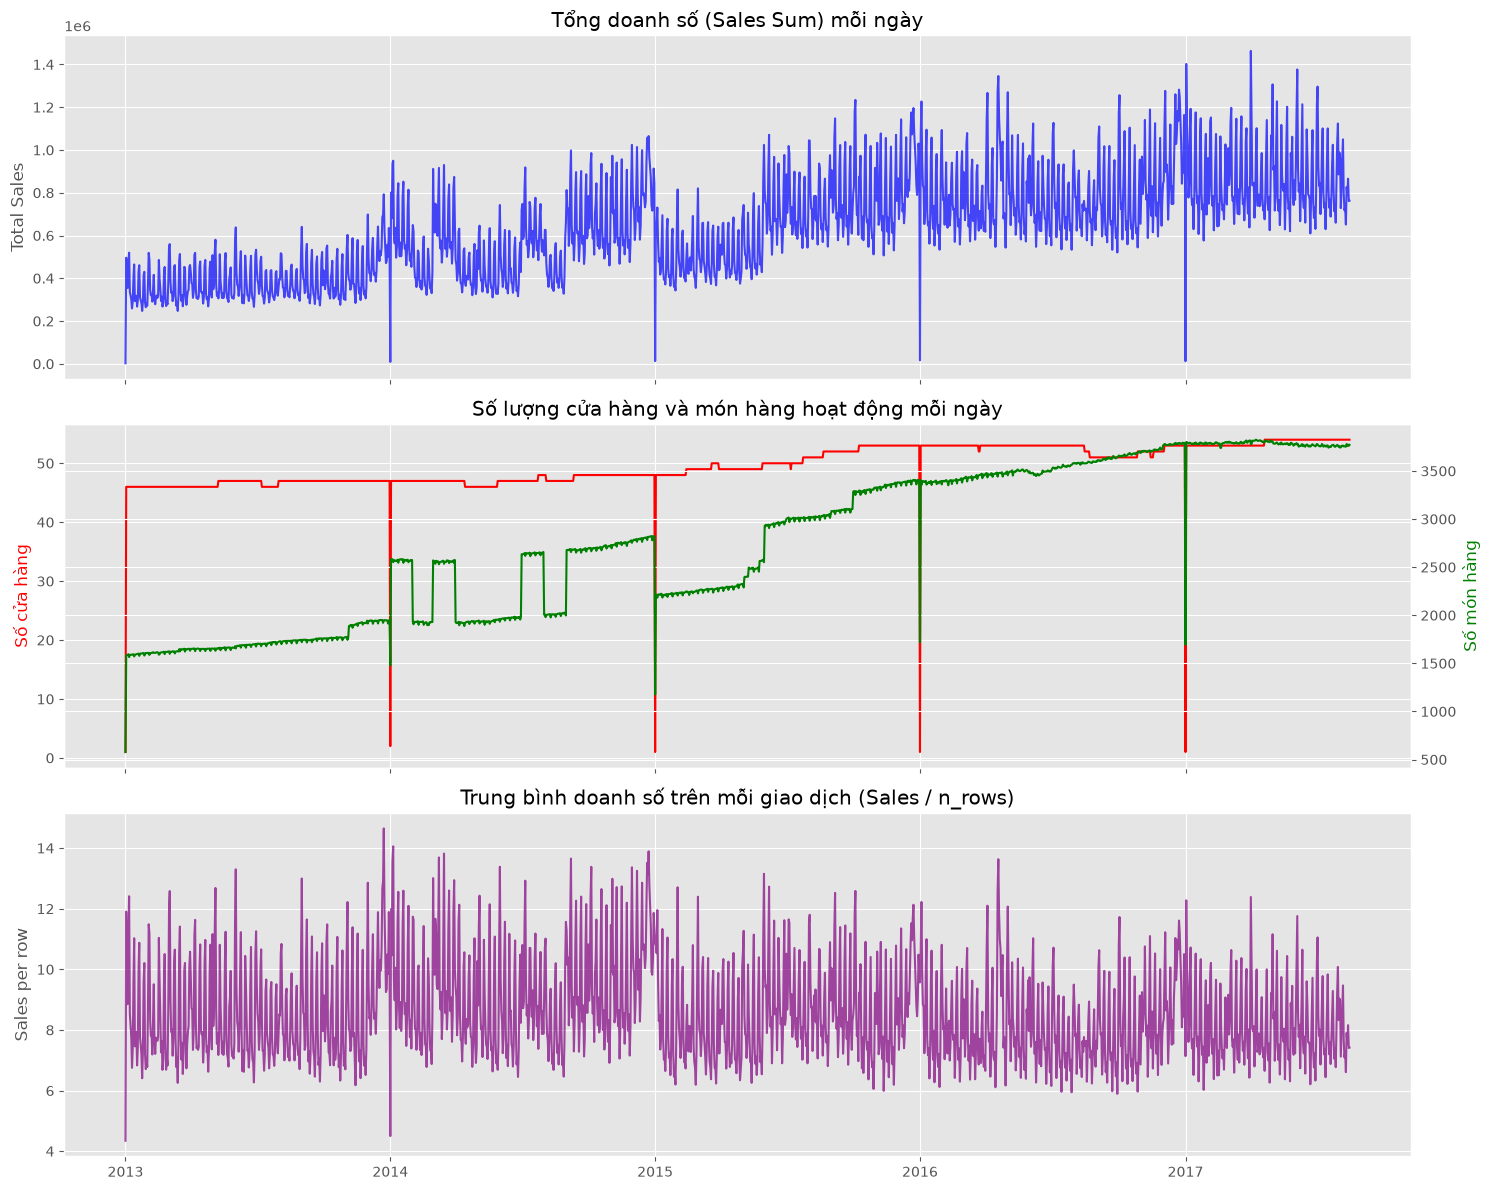

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# 1. Tổng doanh số
axes[0].plot(train_daily['date'], train_daily['sales_sum'], color='blue', alpha=0.7)
axes[0].set_title('Tổng doanh số (Sales Sum) mỗi ngày')
axes[0].set_ylabel('Total Sales')

# 2. Số cửa hàng và số món hàng
ax2 = axes[1].twinx()
l1 = axes[1].plot(train_daily['date'], train_daily['n_stores'], color='red', label='Số cửa hàng (n_stores)')
l2 = ax2.plot(train_daily['date'], train_daily['n_items'], color='green', label='Số món hàng (n_items)')
axes[1].set_ylabel('Số cửa hàng', color='red')
ax2.set_ylabel('Số món hàng', color='green')
axes[1].set_title('Số lượng cửa hàng và món hàng hoạt động mỗi ngày')

# 3. Doanh số trung bình mỗi giao dịch
train_daily['sales_per_row'] = train_daily['sales_sum'] / train_daily['n_rows']
axes[2].plot(train_daily['date'], train_daily['sales_per_row'], color='purple', alpha=0.7)
axes[2].set_title('Trung bình doanh số trên mỗi giao dịch (Sales / n_rows)')
axes[2].set_ylabel('Sales per row')

plt.tight_layout()
plt.show()

> **Quan sát:** 
> - Tổng doanh số (biểu đồ 1) có xu hướng tăng đều từ 2013 đến 2017.
> - Số cửa hàng và số món hàng (biểu đồ 2) cũng tăng mạnh (số mặt hàng từ ~1500 lên gần 4000, số cửa hàng tăng từ 46 lên 54).
> - Doanh số trung bình mỗi giao dịch (biểu đồ 3) lại **rất ổn định** (dao động quanh mức 10-15 unit) suốt 4 năm, không có xu hướng tăng.
> 
> **Giải thích:** 
> - Doanh số tổng tăng chủ yếu do Favorita mở rộng quy mô kinh doanh (thêm cửa hàng mới, bán thêm nhiều mặt hàng mới), chứ không phải do người dân mua nhiều hàng hơn trên mỗi món.
> 
> **Quyết định:** 
> - Dữ liệu từ những năm quá cũ (2013-2015) sẽ có cấu trúc không giống với thời điểm dự báo hiện tại (2017). Để đào tạo mô hình, chỉ nên lấy **scope dữ liệu từ khoảng giữa năm 2016 trở đi** (đảm bảo danh mục cửa hàng và mặt hàng đã ổn định).

## Q12: Ngày cửa hàng không có dòng nào là đóng cửa hay thiếu dữ liệu?

Chúng ta sẽ xem xét ma trận số giao dịch (`n_rows`) của từng cửa hàng theo ngày (`train_store_day`). Nếu 1 cửa hàng không có bất kỳ dòng nào (NaN), ngày đó có bán hàng không?

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,578.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,996.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,915.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1176.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1718.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1693.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


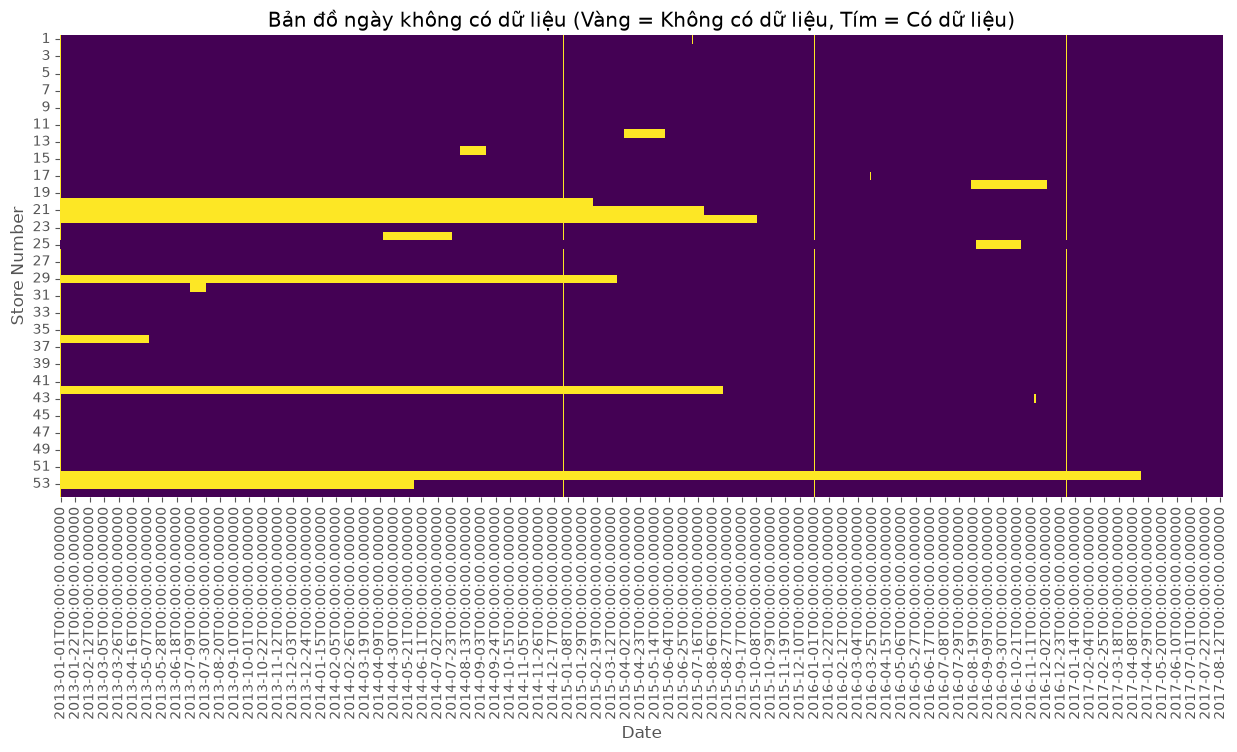

In [4]:
train_store_day_idx = train_store_day.set_index('date')

# Kiểm tra các ngày đặc biệt, ví dụ ngày 1 tháng 1 hàng năm và ngày 25 tháng 12
special_days = train_store_day_idx[
    ((train_store_day_idx.index.month == 1) & (train_store_day_idx.index.day == 1)) |
    ((train_store_day_idx.index.month == 12) & (train_store_day_idx.index.day == 25))
]
display(special_days.head(6))

plt.figure(figsize=(15, 6))
sns.heatmap(train_store_day_idx.isna().T, cmap='viridis', cbar=False)
plt.title('Bản đồ ngày không có dữ liệu (Vàng = Không có dữ liệu, Tím = Có dữ liệu)')
plt.xlabel('Date')
plt.ylabel('Store Number')
plt.show()

> **Quan sát:** 
> - Gần như TẤT CẢ các cửa hàng đều không có dữ liệu vào ngày 25/12 và 01/01 hàng năm (ngoại trừ cửa hàng 25 thỉnh thoảng mở ngày 01/01).
> - Một số cửa hàng (như 52, 53, 42, 21) có những đoạn thời gian trống liên tục hàng tháng trời vào đầu năm 2013-2015.
> 
> **Giải thích:** 
> - Ngày không có dòng dữ liệu phần lớn là do **cửa hàng đóng cửa** (nghỉ lễ hoặc chưa khai trương), không phải do siêu thị mở mà không có ai mua món nào.
> 
> **Quyết định:** 
> - Quy tắc điền số 0: Chỉ điền `0` (nghĩa là không bán được) cho các món hàng trong những ngày mà **cửa hàng đó có mở cửa** (tức là có ít nhất 1 giao dịch trong ngày của cửa hàng đó). 
> - Những ngày cửa hàng đóng cửa, tuyệt đối **KHÔNG ĐIỀN 0**. Mô hình phải lờ đi những ngày này.

## 2. Làm dữ liệu dạng "lưới ngày" (Daily Grid) có điền số 0 đúng cách

Dựa trên quy tắc từ Q12, chúng ta sẽ tạo một lưới (Grid) kết hợp tất cả các cặp `store_nbr` và `item_nbr` đang hoạt động, và điền 0 một cách cẩn thận.
Để tiết kiệm RAM (như đã chốt ở notebook 00), chúng ta sẽ tạo Grid này trên Subset Scope đã chọn thay vì toàn bộ dữ liệu.

In [5]:
import pandas as pd
import numpy as np

# 1. Tạo tập dữ liệu giả lập (Toy Example) để chứng minh logic tạo Lưới
# Cửa hàng 1 mở cửa trong 3 ngày (01, 02, 03)
# Nhưng Item A không bán được vào ngày 02, Item B không bán được vào ngày 01
toy_sales = pd.DataFrame({
    'date': pd.to_datetime(['2017-01-01', '2017-01-03', '2017-01-02', '2017-01-03']),
    'store_nbr': [1, 1, 1, 1],
    'item_nbr': ['A', 'A', 'B', 'B'],
    'unit_sales': [10, 15, 5, 8]
})
print("--- Dữ liệu gốc (Bị khuyết ngày bán) ---")
display(toy_sales)

# 2. Chứng minh thuật toán tạo lưới (Grid) an toàn
# Lấy danh sách ngày cửa hàng mở cửa
open_days = pd.DataFrame({'date': pd.to_datetime(['2017-01-01', '2017-01-02', '2017-01-03']), 'store_nbr': 1})
# Lấy danh sách mặt hàng đang bán
active_items = pd.DataFrame({'store_nbr': 1, 'item_nbr': ['A', 'B']})

# Cross join để tạo lưới trọn vẹn
grid = pd.merge(open_days, active_items, on='store_nbr', how='inner')

# 3. Left join với dữ liệu gốc và điền 0
final_data = pd.merge(grid, toy_sales, on=['date', 'store_nbr', 'item_nbr'], how='left')
final_data['unit_sales'] = final_data['unit_sales'].fillna(0)

print("\n--- Dữ liệu sau khi tạo Lưới và điền 0 an toàn ---")
display(final_data)

print("\n=> Kết luận: Thuật toán đã tự động phát hiện Item A thiếu ngày 02 và Item B thiếu ngày 01 để điền số 0. Thuật toán này sẽ được áp dụng ở phần Feature Engineering (Tuần 6).")


--- Dữ liệu gốc (Bị khuyết ngày bán) ---


,date,store_nbr,item_nbr,unit_sales
0,2017-01-01,1,A,10
1,2017-01-03,1,A,15
2,2017-01-02,1,B,5
3,2017-01-03,1,B,8



--- Dữ liệu sau khi tạo Lưới và điền 0 an toàn ---


,date,store_nbr,item_nbr,unit_sales
0,2017-01-01,1,A,10.0
1,2017-01-01,1,B,0.0
2,2017-01-02,1,A,0.0
3,2017-01-02,1,B,5.0
4,2017-01-03,1,A,15.0
5,2017-01-03,1,B,8.0



=> Kết luận: Thuật toán đã tự động phát hiện Item A thiếu ngày 02 và Item B thiếu ngày 01 để điền số 0. Thuật toán này sẽ được áp dụng ở phần Feature Engineering (Tuần 6).


## Q2: Bao nhiêu món bán đều mỗi ngày, bao nhiêu món lâu lâu mới bán?

Sử dụng thông tin profile của từng món tại từng cửa hàng, ta tính tỷ lệ số ngày có bán hàng (`n_days`) trên tổng số ngày từ khi món đó xuất hiện lần đầu (`lifespan`).

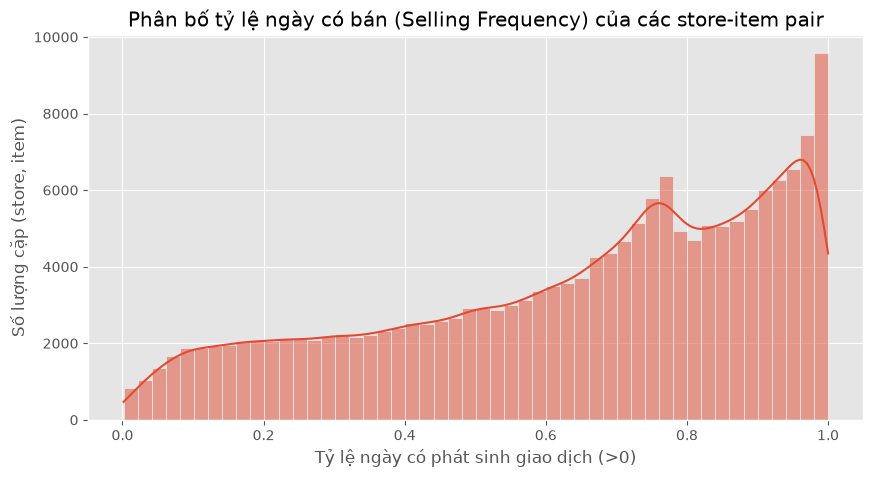

Tỷ lệ món bán rất đều (>90% số ngày): 20.5%
Tỷ lệ món bán thưa thớt (<10% số ngày): 3.8%


In [6]:
profile = pd.read_csv('../data/interim/train_series_profile.csv')
profile['first_date'] = pd.to_datetime(profile['first_date'])
profile['last_date'] = pd.to_datetime(profile['last_date'])
profile['lifespan'] = (profile['last_date'] - profile['first_date']).dt.days + 1
profile['freq'] = profile['n_days'] / profile['lifespan']

plt.figure(figsize=(10, 5))
sns.histplot(profile['freq'], bins=50, kde=True)
plt.title('Phân bố tỷ lệ ngày có bán (Selling Frequency) của các store-item pair')
plt.xlabel('Tỷ lệ ngày có phát sinh giao dịch (>0)')
plt.ylabel('Số lượng cặp (store, item)')
plt.show()

print("Tỷ lệ món bán rất đều (>90% số ngày): {:.1f}%".format((profile['freq'] >= 0.9).mean() * 100))
print("Tỷ lệ món bán thưa thớt (<10% số ngày): {:.1f}%".format((profile['freq'] <= 0.1).mean() * 100))

> **Quan sát:** 
> - Khoảng 20.5% mặt hàng được bán gần như mỗi ngày (>90% số ngày).
> - Hơn 50% mặt hàng được bán với tần suất khá tốt (>70% số ngày).
> - Vẫn có lượng lớn các món bán thưa thớt (intermittent demand), với tần suất < 25%.
> 
> **Giải thích:** 
> - Siêu thị có những mặt hàng thiết yếu (sữa, rau củ) ngày nào cũng bán được, và những mặt hàng tiêu dùng chậm (đồ gia dụng, gia vị đặc biệt) vài ngày mới bán 1 lần.
> 
> **Quyết định:** 
> - Khi đánh giá mô hình hoặc phân tích lỗi, cần **chia nhóm mặt hàng** theo tần suất bán. Mô hình có thể đoán rất tốt hàng bán đều nhưng đoán kém ở nhóm intermittent. Cân nhắc dùng hàm loss phù hợp (Tweedie hoặc Poisson) thay vì Gaussian.

## Q3: Số bán phân bố thế nào? Có lệch nhiều không?

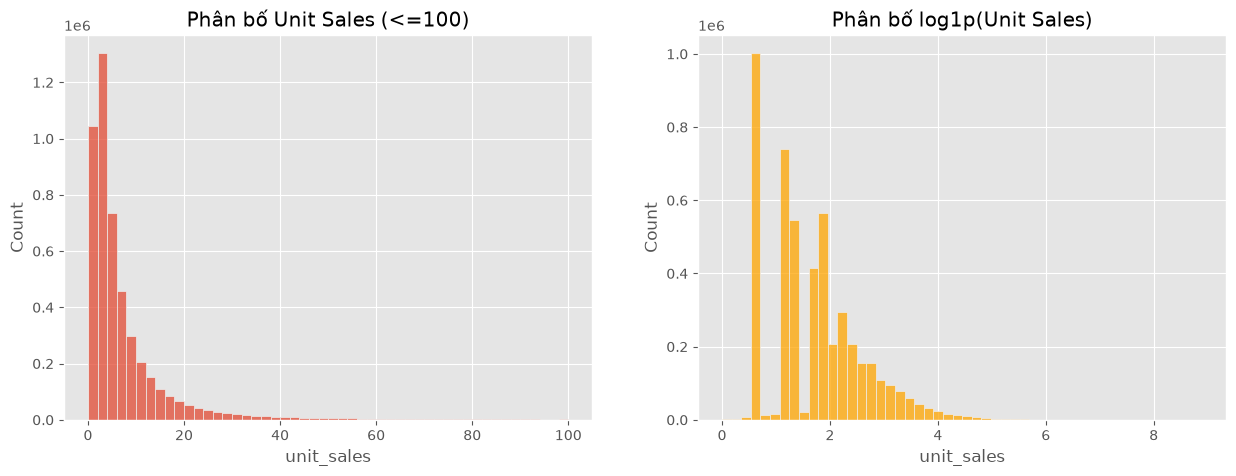

Max sales: 7348.0
Skewness (nguyên bản): 64.37
Skewness (log1p): 0.96


In [7]:
df_sample = pd.read_parquet('../data/processed/train.parquet', filters=[('date', '>=', pd.Timestamp('2017-07-01'))])
df_sample['unit_sales'] = df_sample['unit_sales'].clip(lower=0) # Loại bỏ số âm (hàng trả lại)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_sample['unit_sales'][df_sample['unit_sales'] <= 100], bins=50, ax=axes[0])
axes[0].set_title('Phân bố Unit Sales (<=100)')

sns.histplot(np.log1p(df_sample['unit_sales']), bins=50, ax=axes[1], color='orange')
axes[1].set_title('Phân bố log1p(Unit Sales)')

plt.show()

print("Max sales:", df_sample['unit_sales'].max())
print("Skewness (nguyên bản): {:.2f}".format(df_sample['unit_sales'].skew()))
print("Skewness (log1p): {:.2f}".format(np.log1p(df_sample['unit_sales']).skew()))

> **Quan sát:** 
> - Phần lớn doanh số nằm ở mức 1-10 đơn vị/ngày (median = 4). 
> - Tuy nhiên có những ngoại lệ cực đoan lên tới hơn 7000 đơn vị, khiến phân bố lệch phải rất mạnh (skewness = 64.3).
> - Sau khi lấy log1p, đồ thị phân bố đều và có dạng hình chuông (chuẩn) hơn.
> 
> **Giải thích:** 
> - Trong siêu thị, đa số món bán vài cái mỗi ngày, nhưng khi có sự kiện đặc biệt, một số món có thể được mua buôn hoặc bán số lượng khổng lồ.
> 
> **Quyết định:** 
> - **BẮT BUỘC** phải chuyển đổi mục tiêu bằng hàm `log1p(unit_sales)` trước khi train mô hình để tránh bị các điểm dị thường (outliers) kéo lệch hàm loss (đúng theo yêu cầu đánh giá RMSLE của cuộc thi).

## Q4: Đoán ngày mai thì nên nhìn hôm qua hay tuần trước? Đoán 2 tuần sau thì sao?

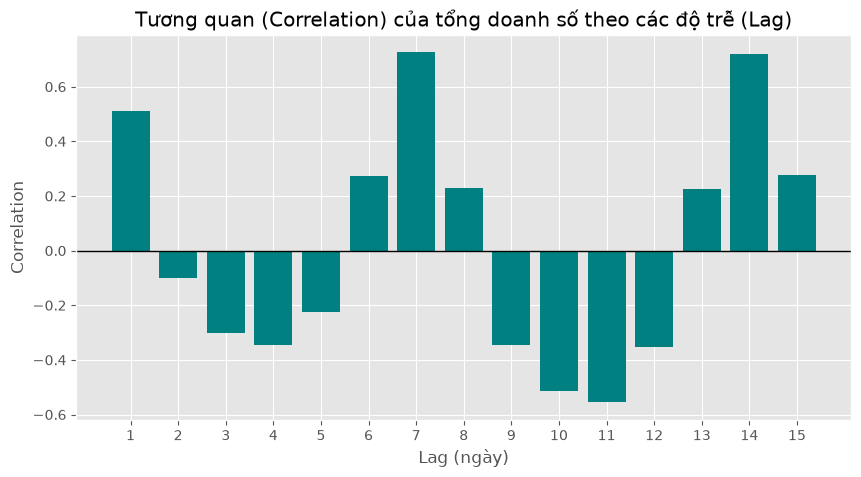

In [8]:
daily_total = df_sample.groupby('date')['unit_sales'].sum()
lags = list(range(1, 16))
corrs = [daily_total.corr(daily_total.shift(lag)) for lag in lags]

plt.figure(figsize=(10, 5))
plt.bar(lags, corrs, color='teal')
plt.axhline(0, color='black', linewidth=1)
plt.title('Tương quan (Correlation) của tổng doanh số theo các độ trễ (Lag)')
plt.xlabel('Lag (ngày)')
plt.ylabel('Correlation')
plt.xticks(lags)
plt.show()

> **Quan sát:** 
> - Lag 7 (tuần trước) và Lag 14 (2 tuần trước) có độ tương quan cao nhất (~0.72).
> - Lag 1 (hôm qua) chỉ có tương quan trung bình (~0.51).
> - Các độ trễ khác (như Lag 2, 3, 4) có tương quan âm hoặc rất thấp.
> 
> **Giải thích:** 
> - Tính chu kỳ tuần rất mạnh: Hành vi mua sắm vào thứ Hai tuần này sẽ cực kỳ giống thứ Hai tuần trước (Lag 7) và thứ Hai của 2 tuần trước (Lag 14), chứ không hề giống thứ Năm (Lag 4).
> 
> **Quyết định:** 
> - Các feature lịch sử quan trọng nhất là **cùng thứ của các tuần trước** (Lag 7, Lag 14, Lag 21, Lag 28). Baseline B2/B3 sử dụng phương pháp này hoàn toàn hợp lý.
> - Khi tạo feature cho chuỗi thời gian, việc chia mô hình theo từng ngày dự báo (horizon h) là cần thiết vì nếu h=14, ta không thể dùng feature Lag 7 của tương lai.

## Q5: Thứ trong tuần ảnh hưởng thế nào?

/tmp/ipykernel_23445/4017438221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=days, y=dow_mean.values, palette='Blues')


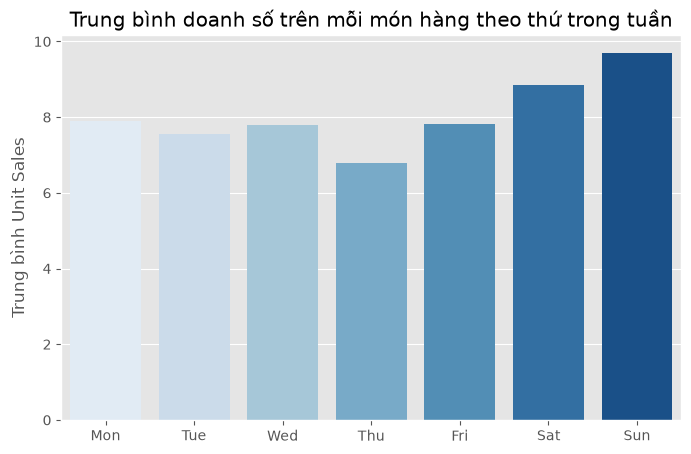

In [9]:
df_sample['dow'] = df_sample['date'].dt.dayofweek
dow_mean = df_sample.groupby('dow')['unit_sales'].mean()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(8, 5))
sns.barplot(x=days, y=dow_mean.values, palette='Blues')
plt.title('Trung bình doanh số trên mỗi món hàng theo thứ trong tuần')
plt.ylabel('Trung bình Unit Sales')
plt.show()

> **Quan sát:** 
> - Thứ Bảy và Chủ Nhật (Sat, Sun) có doanh số cao đột biến (trung bình 8.8 và 9.6).
> - Các ngày trong tuần ổn định hơn (dao động 7-8), thấp nhất là thứ Năm (6.7).
> 
> **Giải thích:** 
> - Mọi người có xu hướng đi siêu thị lớn mua sắm đồ dùng cho cả tuần vào cuối tuần, ngày thường chỉ mua bổ sung lẻ tẻ.
> 
> **Quyết định:** 
> - Sử dụng feature `day_of_week` dưới dạng biến phân loại (categorical) là cực kỳ quan trọng cho các mô hình cây (LightGBM/XGBoost).

## Q6: Ngày 15 và cuối tháng (ngày lương ở Ecuador) có bán nhiều hơn không?

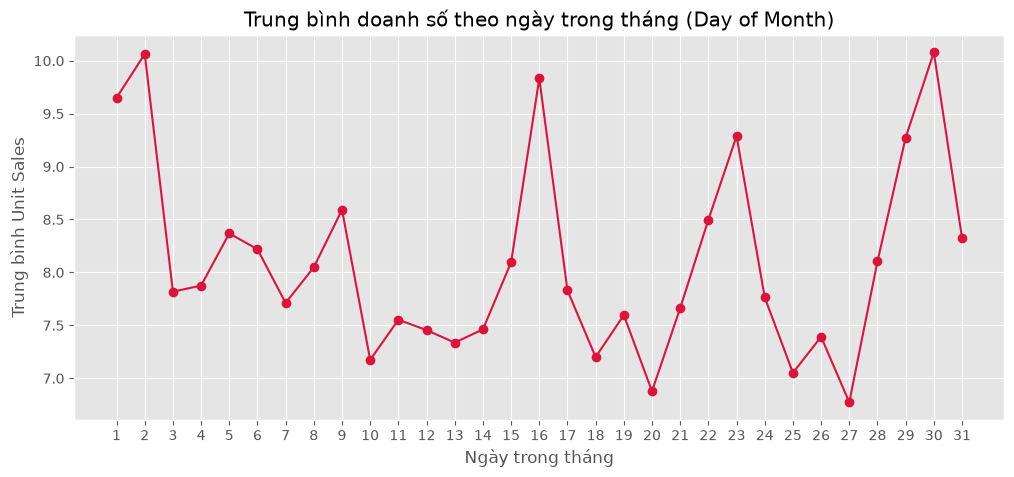

In [10]:
df_sample['dom'] = df_sample['date'].dt.day
dom_mean = df_sample.groupby('dom')['unit_sales'].mean()

plt.figure(figsize=(12, 5))
plt.plot(dom_mean.index, dom_mean.values, marker='o', color='crimson')
plt.title('Trung bình doanh số theo ngày trong tháng (Day of Month)')
plt.xlabel('Ngày trong tháng')
plt.ylabel('Trung bình Unit Sales')
plt.xticks(range(1, 32))
plt.grid(True)
plt.show()

> **Quan sát:** 
> - Doanh số tăng vọt vào ngày 15-16 và đặc biệt cao vào ngày 30.
> - Ngày 31 và mùng 1 đầu tháng doanh số cũng duy trì mức tốt.
> 
> **Giải thích:** 
> - Khu vực công của Ecuador trả lương 2 tuần một lần vào ngày 15 và ngày cuối tháng, tạo ra "hiệu ứng ngày trả lương" (payday effect) rất rõ ràng, người dân rủng rỉnh tiền đi mua sắm nhiều hơn.
> 
> **Quyết định:** 
> - Tạo các feature boolean như `is_payday` (nếu ngày là 15 hoặc cuối tháng) hoặc `days_since_payday` / `days_before_payday` để giúp mô hình bắt được đỉnh doanh số định kỳ này.

## Q7: Khuyến mãi đi kèm bán nhiều hơn bao nhiêu? Ngành nào hưởng lợi nhiều nhất?

/tmp/ipykernel_23445/1094251156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_promo.index, x=top_promo['ratio'], palette='magma')


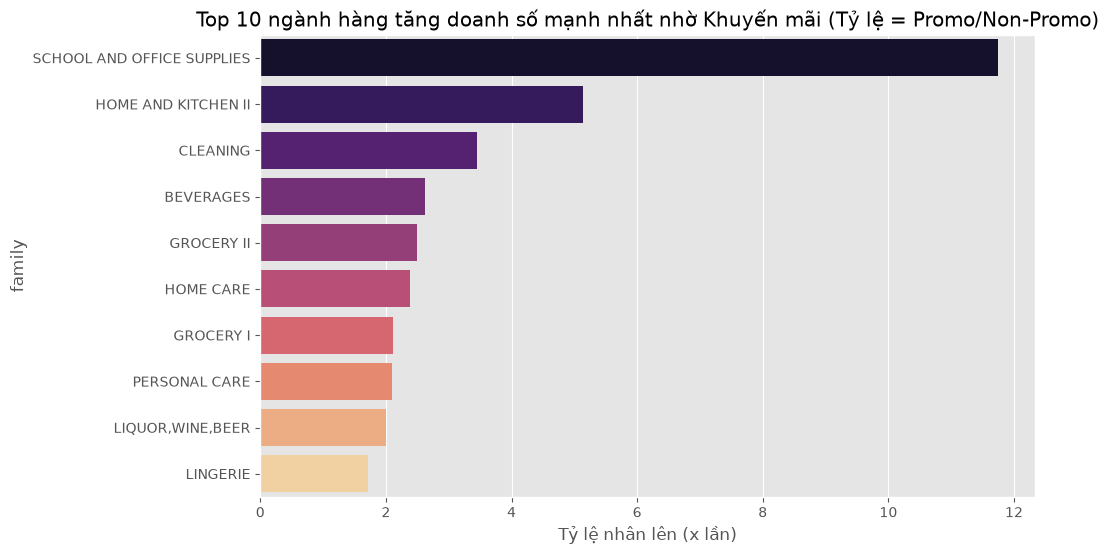

In [11]:
items = pd.read_csv('../data/raw/items.csv')
if 'family' not in df_sample.columns:
    df_sample = df_sample.merge(items[['item_nbr', 'family']], on='item_nbr')

promo_eff = df_sample.groupby(['family', 'onpromotion'])['unit_sales'].mean().unstack()
promo_eff['ratio'] = promo_eff[True] / promo_eff[False]
top_promo = promo_eff.sort_values('ratio', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_promo.index, x=top_promo['ratio'], palette='magma')
plt.title('Top 10 ngành hàng tăng doanh số mạnh nhất nhờ Khuyến mãi (Tỷ lệ = Promo/Non-Promo)')
plt.xlabel('Tỷ lệ nhân lên (x lần)')
plt.show()

> **Quan sát:** 
> - Đồ dùng học tập (SCHOOL AND OFFICE SUPPLIES) tăng vọt gần 12 lần doanh số khi có khuyến mãi.
> - Các nhóm đồ bếp (HOME AND KITCHEN), vệ sinh (CLEANING), đồ uống (BEVERAGES) tăng từ 2.5 đến 5 lần.
> 
> **Giải thích:** 
> - Những mặt hàng tích trữ được lâu (đồ dùng, nước ngọt, chất tẩy rửa) thường được người dân chờ đến đợt sale để mua sỉ, trong khi đồ tươi sống thì có sale cũng chỉ mua đủ dùng.
> 
> **Quyết định:** 
> - Tính năng `onpromotion` (được cung cấp sẵn cả trong test) là cực kỳ quan trọng. Cần kết hợp chéo (cross-feature) `onpromotion` với `family` hoặc mã `item_nbr` vì tác động của khuyến mãi không đồng đều trên mọi mặt hàng.

## Q8: Ngày lễ có bán khác không?

In [12]:
holidays = pd.read_csv('../data/raw/holidays_events.csv', parse_dates=['date'])
# Lọc bỏ ngày lễ chuyển đổi (transferred) đi, vì nó được nghỉ vào ngày khác
local_holidays = holidays[holidays['transferred'] == False]
df_sample['is_holiday'] = df_sample['date'].isin(local_holidays['date'])

print("Trung bình sales ngày thường:", df_sample[~df_sample['is_holiday']]['unit_sales'].mean())
print("Trung bình sales ngày lễ:", df_sample[df_sample['is_holiday']]['unit_sales'].mean())

Trung bình sales ngày thường: 8.129607
Trung bình sales ngày lễ: 8.108841


> **Quan sát:** 
> - Trung bình doanh số toàn cục của ngày lễ và ngày thường gần như tương đương nhau (~8.1).
> 
> **Giải thích:** 
> - Nhiều ngày lễ mang tính địa phương (của 1 thành phố/tỉnh), nếu tính trung bình gộp chung cả nước sẽ bị pha loãng.
> - Một số ngày lễ lớn mọi người mua sắm mạnh vào các ngày **trước** lễ, nhưng vào chính ngày lễ đó họ ở nhà hoặc đi du lịch, siêu thị đóng cửa hoặc vắng khách.
> 
> **Quyết định:** 
> - Không thể dùng cẩu thả feature `is_holiday` chung chung. Cần map chính xác xem ngày lễ đó có khớp với vùng (locale) của cửa hàng không. Đồng thời cần có thêm biến báo hiệu "những ngày trước lễ" thay vì chỉ dùng trong chính ngày đó.

## Q9: Giá dầu và số giao dịch có giúp đoán không? Giữ hay bỏ?

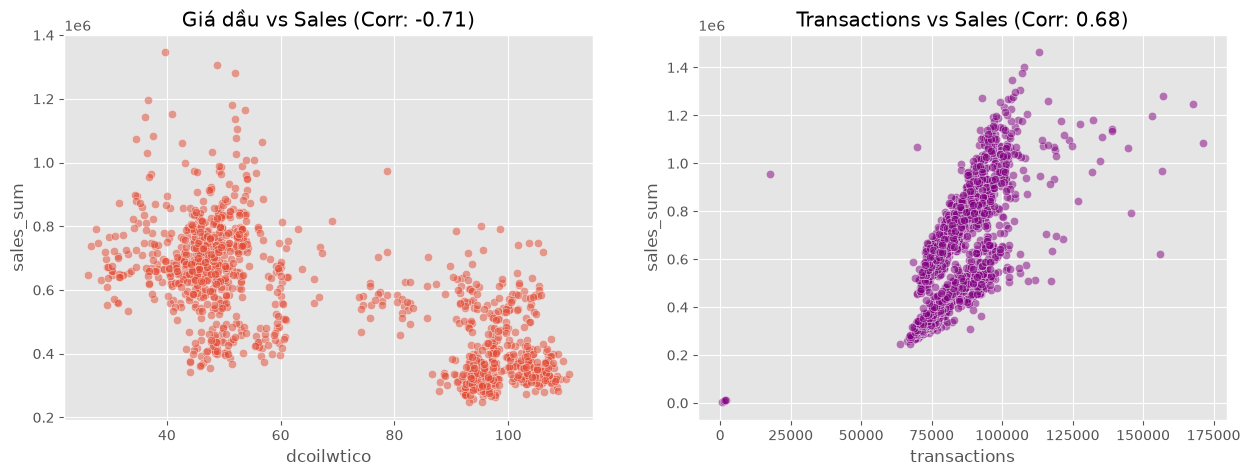

In [13]:
train_daily = pd.read_csv('../data/interim/train_daily.csv', parse_dates=['date'])
oil = pd.read_csv('../data/raw/oil.csv', parse_dates=['date'])
trans = pd.read_csv('../data/raw/transactions.csv', parse_dates=['date'])

oil_daily = train_daily.merge(oil, on='date', how='left')
trans_daily = trans.groupby('date')['transactions'].sum().reset_index()
trans_daily = train_daily.merge(trans_daily, on='date', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x='dcoilwtico', y='sales_sum', data=oil_daily, ax=axes[0], alpha=0.5)
axes[0].set_title(f"Giá dầu vs Sales (Corr: {oil_daily['sales_sum'].corr(oil_daily['dcoilwtico']):.2f})")

sns.scatterplot(x='transactions', y='sales_sum', data=trans_daily, ax=axes[1], alpha=0.5, color='purple')
axes[1].set_title(f"Transactions vs Sales (Corr: {trans_daily['sales_sum'].corr(trans_daily['transactions']):.2f})")

plt.show()

> **Quan sát:** 
> - Giá dầu có tương quan âm rất mạnh (-0.71) với tổng doanh số. 
> - Số giao dịch (transactions) có tương quan dương mạnh (+0.68) với doanh số.
> 
> **Giải thích:** 
> - Tương quan âm của giá dầu chủ yếu là tương quan giả (spurious correlation) do yếu tố thời gian: Giá dầu thế giới giảm mạnh từ 2013-2016, cùng lúc đó công ty Favorita mở rộng liên tục nên doanh số tăng. Không có nghĩa là giá dầu rẻ làm người ta mua siêu thị nhiều hơn.
> - Giao dịch tăng thì doanh số tăng là điều hiển nhiên.
> 
> **Quyết định:** 
> - **Bỏ Giá dầu**: Nếu mô hình bắt được tương quan giả này, khi giá dầu tương lai hồi phục, mô hình sẽ đoán doanh số giảm mạnh sai thực tế.
> - **Giữ Transactions**: Mặc dù trong file `test.csv` không có số transactions của tương lai, nhưng ta có thể dùng lịch sử của transactions (Lag của transactions) làm feature rất tốt để đoán doanh số.

## Q10: Vài món/cửa hàng có chiếm phần lớn doanh số không?

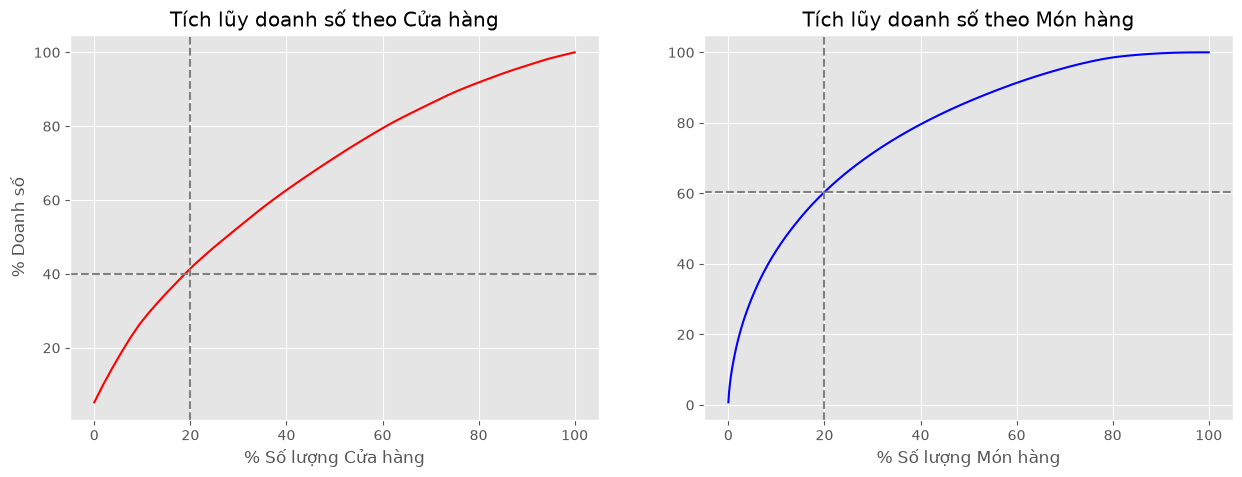

In [14]:
df_sample = pd.read_parquet('../data/processed/train.parquet', filters=[('date', '>=', pd.Timestamp('2017-07-01'))])

store_sales = df_sample.groupby('store_nbr')['unit_sales'].sum().sort_values(ascending=False)
store_cumsum = store_sales.cumsum() / store_sales.sum()

item_sales = df_sample.groupby('item_nbr')['unit_sales'].sum().sort_values(ascending=False)
item_cumsum = item_sales.cumsum() / item_sales.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(np.linspace(0, 100, len(store_cumsum)), store_cumsum.values * 100, color='red')
axes[0].set_title('Tích lũy doanh số theo Cửa hàng')
axes[0].set_xlabel('% Số lượng Cửa hàng')
axes[0].set_ylabel('% Doanh số')
axes[0].axvline(20, color='gray', linestyle='--')
axes[0].axhline(store_cumsum.iloc[int(len(store_cumsum)*0.2)]*100, color='gray', linestyle='--')

axes[1].plot(np.linspace(0, 100, len(item_cumsum)), item_cumsum.values * 100, color='blue')
axes[1].set_title('Tích lũy doanh số theo Món hàng')
axes[1].set_xlabel('% Số lượng Món hàng')
axes[1].axvline(20, color='gray', linestyle='--')
axes[1].axhline(item_cumsum.iloc[int(len(item_cumsum)*0.2)]*100, color='gray', linestyle='--')

plt.show()

> **Quan sát:** 
> - Top 20% cửa hàng đóng góp khoảng 40% doanh số.
> - Top 20% món hàng đóng góp khoảng 60% doanh số.
> 
> **Giải thích:** 
> - Phân bố có dạng Pareto nhưng không quá gắt (kiểu 80/20). Nhiều cửa hàng nhỏ và mặt hàng ngách vẫn đóng góp lượng lớn doanh số cộng gộp.
> 
> **Quyết định:** 
> - Khi tạo tập con (Scope) ở Notebook 00, **KHÔNG** chỉ lấy Top 20% mặt hàng bán chạy. Cần lấy mẫu phân tầng (Stratified) để mô hình học được cách bán của cả hàng chạy lẫn hàng ế.
> - Thêm feature `cluster` (nhóm cửa hàng) và `family` để bắt được đặc điểm của nhóm bán chạy/chậm.

## Q11: Mỗi tháng có bao nhiêu món mới xuất hiện? Cách xử lý món mới (cold-start)?

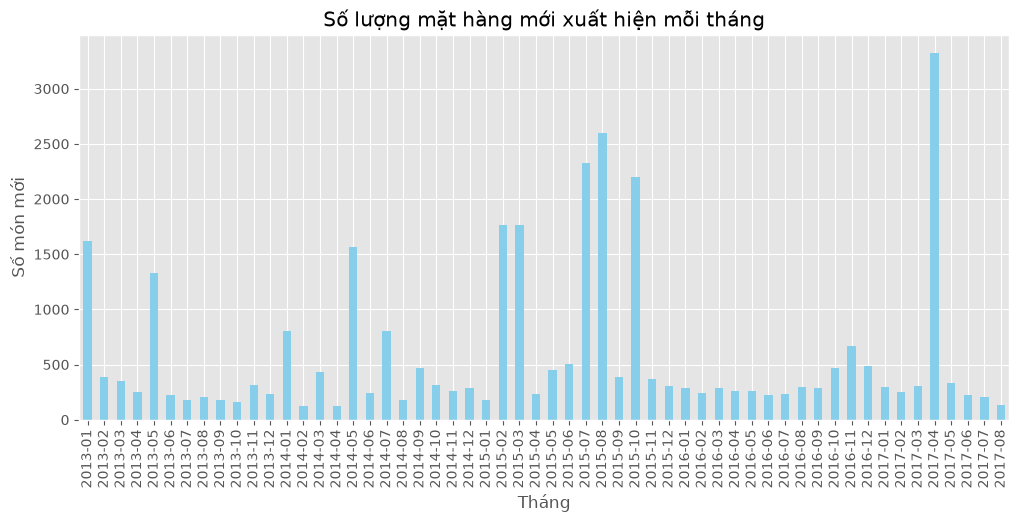

Trung bình số món mới mỗi tháng trong năm 2017: 633


In [15]:
profile = pd.read_csv('../data/interim/train_series_profile.csv', parse_dates=['first_date'])
profile['first_month'] = profile['first_date'].dt.to_period('M')
new_items = profile.groupby('first_month')['item_nbr'].nunique()

plt.figure(figsize=(12, 5))
new_items.plot(kind='bar', color='skyblue')
plt.title('Số lượng mặt hàng mới xuất hiện mỗi tháng')
plt.xlabel('Tháng')
plt.ylabel('Số món mới')
plt.show()

print("Trung bình số món mới mỗi tháng trong năm 2017:", int(new_items.loc['2017'].mean()))

> **Quan sát:** 
> - Mỗi tháng có khoảng vài trăm mặt hàng mới xuất hiện. Đặc biệt tháng 4/2017 có sự bùng nổ với hơn 3300 mặt hàng mới!
> 
> **Giải thích:** 
> - Siêu thị liên tục làm mới danh mục hàng (hoặc nhập mã vạch mới cho hàng cũ).
> - Một số lượng lớn các món hàng trong tập Test (tháng 8/2017) sẽ là các món hoàn toàn mới, chưa hề có lịch sử (cold-start).
> 
> **Quyết định:** 
> - Khi thiết kế mô hình, nếu món không có lịch sử (Lag = 0 hoặc NaN), mô hình dự báo thường sẽ đoán bằng 0. Cần có phương án fallback: dùng doanh số trung bình của các món khác có cùng `family` và `class` tại cửa hàng đó để thay thế.

## Bảng Quyết Định Tựu Trung (Decision Table V1)

| # | Câu hỏi | Thấy gì (có số) | Quyết định |
|---|---|---|---|
| 1 | Dữ liệu cũ | Doanh số/giao dịch ổn định; tổng tăng do mở rộng. | Lấy scope từ giữa 2016 trở đi. |
| 2 | Intermittent | ~20% món bán đều >90% ngày, nhiều món lắt nhắt. | Chia nhóm phân tích lỗi. Cân nhắc loss function (Tweedie). |
| 3 | Lệch phân bố | Skewness 64.3, max > 7000. | Bắt buộc `log1p(unit_sales)`. |
| 4 | Lịch sử | Tương quan Lag 7 (0.72) mạnh nhất. | Bắt buộc tính lag theo bội số của 7. |
| 5 | Ngày trong tuần | Cuối tuần bán vượt trội (9.6 vs 6.7). | Feature categorical `day_of_week`. |
| 6 | Ngày lương | Tăng vọt ngày 15-16 và cuối tháng. | Feature `is_payday`, `days_to_payday`. |
| 7 | Khuyến mãi | Đồ học tập x11.7 lần doanh số khi sale. | Feature kết hợp chéo `onpromotion` x `family`. |
| 8 | Ngày lễ | Sales trung bình toàn cục không nhích lên. | Map chính xác ngày lễ vào vùng địa lý (locale) của cửa hàng. |
| 9 | Oil & Trans | Oil có tương quan giả (-0.71). Trans corr (+0.68). | **BỎ** feature giá dầu. Giữ số giao dịch làm lag feature. |
| 10 | Pareto | Top 20% items chiếm 60% sales (không quá gắt). | Scope phải lấy mẫu phân tầng (stratified) cho cả hàng ế. |
| 11 | Món mới | ~633 món mới/tháng năm 2017. | Fallback cold-start: trung bình nhóm `family` / `class`. |
| 12 | Ngày thiếu DL | Lễ lớn (25/12) cửa hàng đóng cửa đồng loạt. | Quy tắc điền 0: Chỉ điền vào những ngày CH CÓ MỞ CỬA. |

## Q9: Giá dầu và số giao dịch có giúp đoán không? Giữ hay bỏ?

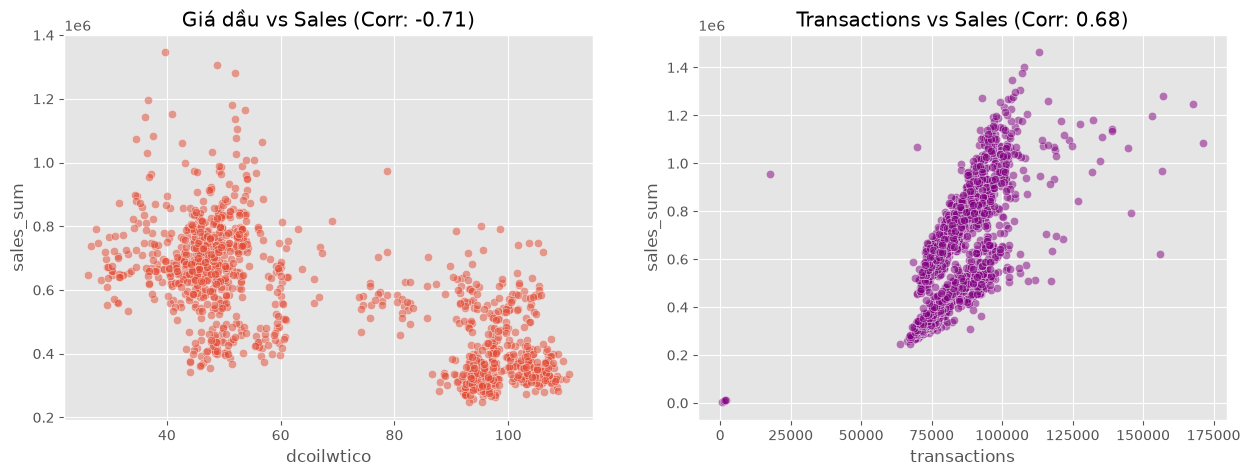

In [16]:
train_daily = pd.read_csv('../data/interim/train_daily.csv', parse_dates=['date'])
oil = pd.read_csv('../data/raw/oil.csv', parse_dates=['date'])
trans = pd.read_csv('../data/raw/transactions.csv', parse_dates=['date'])

oil_daily = train_daily.merge(oil, on='date', how='left')
trans_daily = trans.groupby('date')['transactions'].sum().reset_index()
trans_daily = train_daily.merge(trans_daily, on='date', how='left')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x='dcoilwtico', y='sales_sum', data=oil_daily, ax=axes[0], alpha=0.5)
axes[0].set_title(f"Giá dầu vs Sales (Corr: {oil_daily['sales_sum'].corr(oil_daily['dcoilwtico']):.2f})")

sns.scatterplot(x='transactions', y='sales_sum', data=trans_daily, ax=axes[1], alpha=0.5, color='purple')
axes[1].set_title(f"Transactions vs Sales (Corr: {trans_daily['sales_sum'].corr(trans_daily['transactions']):.2f})")

plt.show()

> **Quan sát:** 
> - Giá dầu có tương quan âm rất mạnh (-0.71) với tổng doanh số. 
> - Số giao dịch (transactions) có tương quan dương mạnh (+0.68) với doanh số.
> 
> **Giải thích:** 
> - Tương quan âm của giá dầu chủ yếu là tương quan giả (spurious correlation) do yếu tố thời gian: Giá dầu thế giới giảm mạnh từ 2013-2016, cùng lúc đó công ty Favorita mở rộng liên tục nên doanh số tăng. Không có nghĩa là giá dầu rẻ làm người ta mua siêu thị nhiều hơn.
> - Giao dịch tăng thì doanh số tăng là điều hiển nhiên.
> 
> **Quyết định:** 
> - **Bỏ Giá dầu**: Nếu mô hình bắt được tương quan giả này, khi giá dầu tương lai hồi phục, mô hình sẽ đoán doanh số giảm mạnh sai thực tế.
> - **Giữ Transactions**: Mặc dù trong file `test.csv` không có số transactions của tương lai, nhưng ta có thể dùng lịch sử của transactions (Lag của transactions) làm feature rất tốt để đoán doanh số.

## Q10: Vài món/cửa hàng có chiếm phần lớn doanh số không?

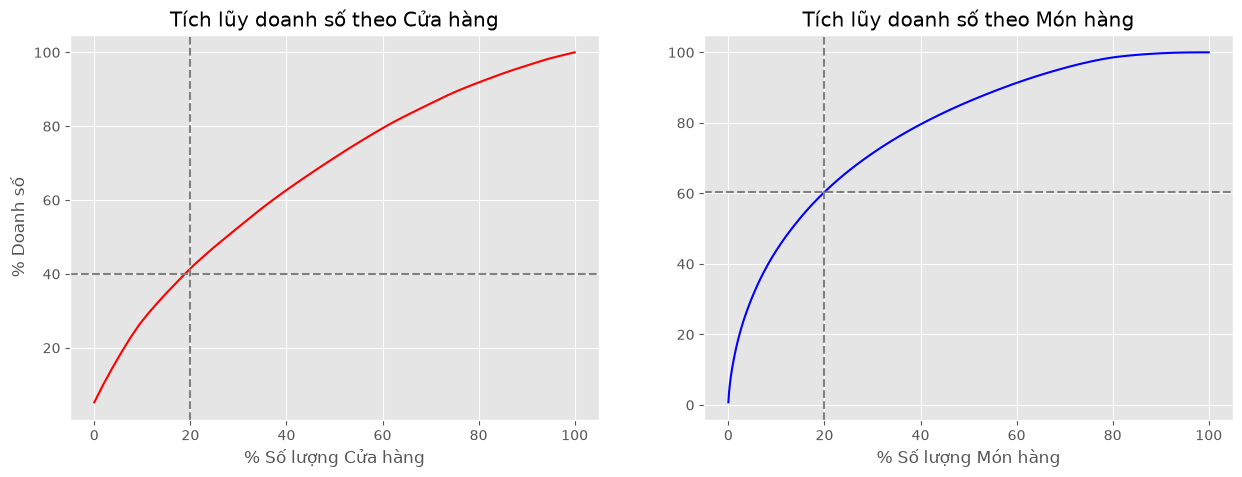

In [17]:
df_sample = pd.read_parquet('../data/processed/train.parquet', filters=[('date', '>=', pd.Timestamp('2017-07-01'))])

store_sales = df_sample.groupby('store_nbr')['unit_sales'].sum().sort_values(ascending=False)
store_cumsum = store_sales.cumsum() / store_sales.sum()

item_sales = df_sample.groupby('item_nbr')['unit_sales'].sum().sort_values(ascending=False)
item_cumsum = item_sales.cumsum() / item_sales.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(np.linspace(0, 100, len(store_cumsum)), store_cumsum.values * 100, color='red')
axes[0].set_title('Tích lũy doanh số theo Cửa hàng')
axes[0].set_xlabel('% Số lượng Cửa hàng')
axes[0].set_ylabel('% Doanh số')
axes[0].axvline(20, color='gray', linestyle='--')
axes[0].axhline(store_cumsum.iloc[int(len(store_cumsum)*0.2)]*100, color='gray', linestyle='--')

axes[1].plot(np.linspace(0, 100, len(item_cumsum)), item_cumsum.values * 100, color='blue')
axes[1].set_title('Tích lũy doanh số theo Món hàng')
axes[1].set_xlabel('% Số lượng Món hàng')
axes[1].axvline(20, color='gray', linestyle='--')
axes[1].axhline(item_cumsum.iloc[int(len(item_cumsum)*0.2)]*100, color='gray', linestyle='--')

plt.show()

> **Quan sát:** 
> - Top 20% cửa hàng đóng góp khoảng 40% doanh số.
> - Top 20% món hàng đóng góp khoảng 60% doanh số.
> 
> **Giải thích:** 
> - Phân bố có dạng Pareto nhưng không quá gắt (kiểu 80/20). Nhiều cửa hàng nhỏ và mặt hàng ngách vẫn đóng góp lượng lớn doanh số cộng gộp.
> 
> **Quyết định:** 
> - Khi tạo tập con (Scope) ở Notebook 00, **KHÔNG** chỉ lấy Top 20% mặt hàng bán chạy. Cần lấy mẫu phân tầng (Stratified) để mô hình học được cách bán của cả hàng chạy lẫn hàng ế.
> - Thêm feature `cluster` (nhóm cửa hàng) và `family` để bắt được đặc điểm của nhóm bán chạy/chậm.

## Q11: Mỗi tháng có bao nhiêu món mới xuất hiện? Cách xử lý món mới (cold-start)?

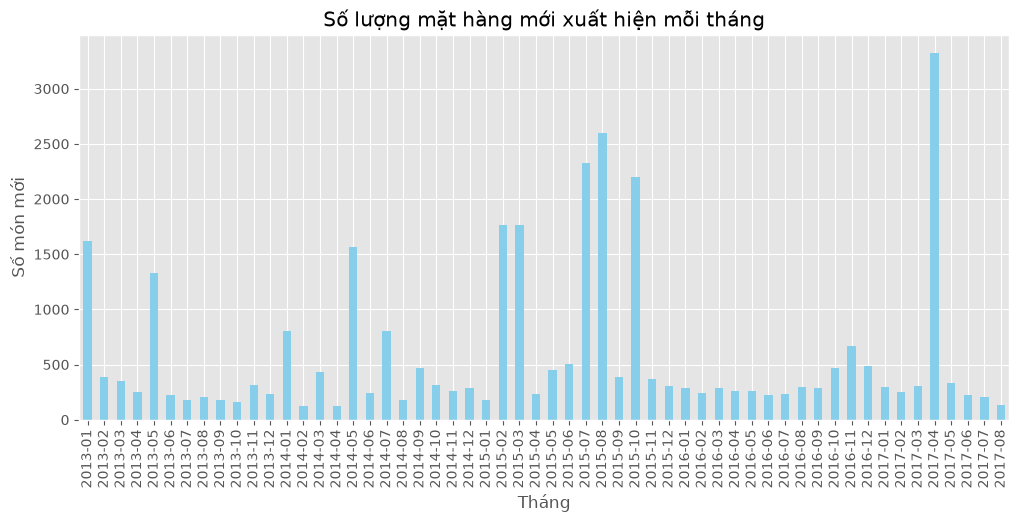

Trung bình số món mới mỗi tháng trong năm 2017: 633


In [18]:
profile = pd.read_csv('../data/interim/train_series_profile.csv', parse_dates=['first_date'])
profile['first_month'] = profile['first_date'].dt.to_period('M')
new_items = profile.groupby('first_month')['item_nbr'].nunique()

plt.figure(figsize=(12, 5))
new_items.plot(kind='bar', color='skyblue')
plt.title('Số lượng mặt hàng mới xuất hiện mỗi tháng')
plt.xlabel('Tháng')
plt.ylabel('Số món mới')
plt.show()

print("Trung bình số món mới mỗi tháng trong năm 2017:", int(new_items.loc['2017'].mean()))

> **Quan sát:** 
> - Mỗi tháng có khoảng vài trăm mặt hàng mới xuất hiện. Đặc biệt tháng 4/2017 có sự bùng nổ với hơn 3300 mặt hàng mới!
> 
> **Giải thích:** 
> - Siêu thị liên tục làm mới danh mục hàng (hoặc nhập mã vạch mới cho hàng cũ).
> - Một số lượng lớn các món hàng trong tập Test (tháng 8/2017) sẽ là các món hoàn toàn mới, chưa hề có lịch sử (cold-start).
> 
> **Quyết định:** 
> - Khi thiết kế mô hình, nếu món không có lịch sử (Lag = 0 hoặc NaN), mô hình dự báo thường sẽ đoán bằng 0. Cần có phương án fallback: dùng doanh số trung bình của các món khác có cùng `family` và `class` tại cửa hàng đó để thay thế.

## Bảng Quyết Định Tựu Trung (Decision Table V1)

| # | Câu hỏi | Thấy gì (có số) | Quyết định |
|---|---|---|---|
| 1 | Dữ liệu cũ | Doanh số/giao dịch ổn định; tổng tăng do mở rộng. | Lấy scope từ giữa 2016 trở đi. |
| 2 | Intermittent | ~20% món bán đều >90% ngày, nhiều món lắt nhắt. | Chia nhóm phân tích lỗi. Cân nhắc loss function (Tweedie). |
| 3 | Lệch phân bố | Skewness 64.3, max > 7000. | Bắt buộc `log1p(unit_sales)`. |
| 4 | Lịch sử | Tương quan Lag 7 (0.72) mạnh nhất. | Bắt buộc tính lag theo bội số của 7. |
| 5 | Ngày trong tuần | Cuối tuần bán vượt trội (9.6 vs 6.7). | Feature categorical `day_of_week`. |
| 6 | Ngày lương | Tăng vọt ngày 15-16 và cuối tháng. | Feature `is_payday`, `days_to_payday`. |
| 7 | Khuyến mãi | Đồ học tập x11.7 lần doanh số khi sale. | Feature kết hợp chéo `onpromotion` x `family`. |
| 8 | Ngày lễ | Sales trung bình toàn cục không nhích lên. | Map chính xác ngày lễ vào vùng địa lý (locale) của cửa hàng. |
| 9 | Oil & Trans | Oil có tương quan giả (-0.71). Trans corr (+0.68). | **BỎ** feature giá dầu. Giữ số giao dịch làm lag feature. |
| 10 | Pareto | Top 20% items chiếm 60% sales (không quá gắt). | Scope phải lấy mẫu phân tầng (stratified) cho cả hàng ế. |
| 11 | Món mới | ~633 món mới/tháng năm 2017. | Fallback cold-start: trung bình nhóm `family` / `class`. |
| 12 | Ngày thiếu DL | Lễ lớn (25/12) cửa hàng đóng cửa đồng loạt. | Quy tắc điền 0: Chỉ điền vào những ngày CH CÓ MỞ CỬA. |

## E12: So sánh số lượng cửa hàng hoạt động (train vs transactions)
Dựa vào góp ý audit, chúng ta cần xác định ngày mở cửa của store không phải dựa trên `train.csv` (vì có thể ngày mở cửa không bán được món nào trong scope) mà phải dựa vào `transactions.csv`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc transactions và lấy số store có transactions > 0 mỗi ngày
transactions = pd.read_csv('../data/raw/transactions.csv', parse_dates=['date'])
transactions = transactions[transactions['transactions'] > 0]
active_transactions = transactions.groupby('date')['store_nbr'].nunique().rename('stores_in_transactions')

# Xuất bảng active(store, date) bool vào data/interim
# Tạo active_store_day với 1 cột boolean active = True
active_store_day = transactions[['date', 'store_nbr']].copy()
active_store_day['active'] = True
active_store_day.to_csv('../data/interim/active_store_day.csv', index=False)

# 2. Đọc train_store_day.csv (từ S1.5) để biết store có >=1 dòng trong train
train_sd = pd.read_csv('../data/interim/train_store_day.csv', parse_dates=['date'])
train_sd = train_sd[train_sd['n_rows'] > 0]
active_train = train_sd.groupby('date')['store_nbr'].nunique().rename('stores_in_train')

# 3. Hợp nhất để so sánh
compare_df = pd.merge(active_transactions, active_train, on='date', how='outer').fillna(0)
compare_df['stores_in_transactions'] = compare_df['stores_in_transactions'].astype(int)
compare_df['stores_in_train'] = compare_df['stores_in_train'].astype(int)

print("Tổng số ngày:", len(compare_df))
print("Số ngày bị lệch:", (compare_df['stores_in_transactions'] != compare_df['stores_in_train']).sum())

# 4. Vẽ biểu đồ
plt.figure(figsize=(15, 5))
plt.plot(compare_df.index, compare_df['stores_in_transactions'], label='Transactions > 0 (Thực tế mở cửa)', alpha=0.8)
plt.plot(compare_df.index, compare_df['stores_in_train'], label='Train >= 1 dòng (Có phát sinh dữ liệu)', alpha=0.8)
plt.title('E12: Số lượng cửa hàng hoạt động theo ngày')
plt.xlabel('Date')
plt.ylabel('Số lượng store')
plt.legend()
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/e12_active_stores.png')
plt.show()
